<a href="https://colab.research.google.com/github/AlishaZaheer1/Projects/blob/main/Satellite_Image_Analyzation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    # RSVQAxBEN Model definition, training and evaluation

## 1) Definition of the data loader and encoder

In [ ]:
from comet_ml import Experiment
import json
from tqdm import tqdm

MAX_ANSWERS = 1000
LEN_QUESTION = 20

class VocabEncoder():
  def __init__(self, JSONFile, questions=True):
    self.encoder_type = 'answer'
    if questions:
      self.encoder_type = 'question'
    self.questions = questions

    words = {}

    print(f"Reading {JSONFile}..", flush= True, end="")
    with open(JSONFile) as json_data:
      data = json.load(json_data)[self.encoder_type + 's']
    print("Done.")

    print(f"Parsing {JSONFile}..", flush= True, end="")
    for i in tqdm(range(len(data))):
      if data[i]["active"]:
        sentence = data[i][self.encoder_type]
        if sentence[-1] == "?" or sentence[-1] == ".":
          sentence = sentence[:-1]

        tokens = sentence.split()
        for tok in tokens:
          tok = tok.lower()
          if tok not in words:
            words[tok] = 1
          else:
            words[tok] += 1

    #Free the memory:
    data = None
    print("Done.")

    sorted_words = sorted(words.items(), key=lambda kv: kv[1], reverse=True)
    print(f"List of words found: {sorted_words}")
    self.words = {'<eos>':0}
    self.list_words = ['<eos>']
    for i, word in enumerate(sorted_words):
      if self.encoder_type == 'answer':
        if i >= MAX_ANSWERS:
          break
      self.words[word[0]] = i + 1
      self.list_words.append(word[0])

  def encode(self, sentence):
    res = []
    if sentence[-1] == "?" or sentence[-1] == ".":
      sentence = sentence[:-1]

    tokens = sentence.split()
    for tok in tokens:
      tok = tok.lower()
      res.append(self.words[tok] + 1)

    res.append(self.words['<eos>'] + 1)

    if self.questions:
      while len(res) < LEN_QUESTION:
        res.append(0)
      res = res[:LEN_QUESTION]
    return res


  def getVocab(self):
    return self.list_words

  def decode(self, sentence):
    res = ""
    for i in sentence:
      if (self.list_words[i - 1] == "<eos>"):
        break
      res += self.list_words[i - 1]
      res += " "
    res = res[:-1] #remove last space
    if self.questions:
      res += "?"
    return res


In [ ]:
encoder_questions = VocabEncoder("/home/student/khan/vqa/LRBENquestions.json", questions=True)
encoder_answers = VocabEncoder("/home/student/khan/vqa/LRBENanswers.json", questions=False)

Reading /home/student/khan/vqa/LRBENquestions.json..Done.
Parsing /home/student/khan/vqa/LRBENquestions.json..

100%|██████████████████████████████████████████████████████████████████| 14758150/14758150 [00:56<00:00, 262407.91it/s]


Done.
List of words found: [('are', 14758150), ('in', 9653032), ('the', 9291465), ('there', 6295016), ('some', 6114183), ('present', 5954444), ('areas', 4888928), ('and', 4787619), ('image', 4400876), ('scene', 4399839), ('land', 3647267), ('or', 3501338), ('classes', 2846757), ('agricultural', 2113543), ('wetlands', 2013231), ('forest', 1943481), ('water', 1899847), ('cover', 1657723), ('artificial', 1631795), ('bodies', 1590253), ('what', 1575819), ('arable', 1466111), ('which', 1270938), ('waters', 1198635), ('inland', 1150434), ('urban', 1118943), ('forests', 1035504), ('fabric', 918792), ('coniferous', 914116), ('mixed', 871449), ('pastures', 871375), ('addition', 852317), ('to', 852317), ('besides', 851745), ('transitional', 776122), ('heterogeneous', 743159), ('non-irrigated', 732581), ('natural', 724905), ('crops', 724781), ('marine', 699624), ('with', 694785), ('broad-leaved', 635792), ('woodland/shrub', 622851), ('vegetation', 608011), ('permanent', 578210), ('principally', 5

100%|██████████████████████████████████████████████████████████████████| 14758150/14758150 [00:21<00:00, 676071.80it/s]

Done.
List of words found: [('no', 7320314), ('yes', 4591079), ('and', 1662640), ('land', 1012072), ('forest', 810342), ('arable', 800156), ('areas', 788545), ('forest,', 619288), ('mixed', 543087), ('non-irrigated', 528964), ('coniferous', 508847), ('agricultural', 475963), ('transitional', 462807), ('woodland/shrub', 462256), ('natural', 434149), ('none', 418265), ('with', 418103), ('principally', 400378), ('occupied', 400378), ('by', 400378), ('agriculture,', 400378), ('significant', 400378), ('of', 400378), ('broad-leaved', 377696), ('water', 336485), ('pastures', 328717), ('urban', 312468), ('complex', 299599), ('cultivation', 299599), ('bodies', 296618), ('areas,', 289231), ('vegetation', 271573), ('heterogeneous', 246066), ('land,', 228784), ('forests', 192226), ('fabric', 185021), ('discontinuous', 178061), ('patterns,', 172848), ('waters', 159544), ('vegetation,', 155882), ('inland', 128371), ('patterns', 126751), ('fabric,', 125116), ('artificial', 105454), ('agro-forestry', 

In [ ]:
import os.path
import json
import random
from tqdm import tqdm

import numpy as np
from skimage import io

from torch.utils.data import Dataset
import torchvision.transforms as T


class VQALoader(Dataset):
    def __init__(self, imgFolder, images_file, questions_file, answers_file, encoder_questions, encoder_answers, train=True, ratio_images_to_use=1, transform=None, number_outputs=1000, selected_answers=None, patch_size=120):
        self.transform = transform
        self.encoder_questions = encoder_questions  # Keep this if needed elsewhere
        self.encoder_answers = encoder_answers      # Keep this if needed elsewhere
        self.train = train
        self.imgFolder = imgFolder

        print("Loading JSONs...", flush=True, end="")
        with open(questions_file) as json_data:
            questionsJSON = json.load(json_data)

        with open(answers_file) as json_data:
            answersJSON = json.load(json_data)

        with open(images_file) as json_data:
            imagesJSON = json.load(json_data)
        print("Done.", flush=True)

        images = [img['id'] for img in imagesJSON['images'] if img['active']]
        images = images[:int(len(images)*ratio_images_to_use)]
        self.img_ids = images

        print("Construction of the Dataset", flush=True, end="")
        if train:
            self.freq_dict = {}
            for image in tqdm(images):
                for questionid in imagesJSON['images'][image]['questions_ids']:
                    question = questionsJSON['questions'][questionid]
                    answer_str = answersJSON['answers'][question["answers_ids"][0]]['answer']
                    if answer_str not in self.freq_dict:
                        self.freq_dict[answer_str] = 1
                    else:
                        self.freq_dict[answer_str] += 1

            self.freq_dict = sorted(self.freq_dict.items(), key=lambda x: x[1], reverse=True)
            self.selected_answers = []
            self.non_selected_answers = []
            coverage = 0
            total_answers = 0

            for i, key in enumerate(self.freq_dict):
                if i < number_outputs:
                    self.selected_answers.append(key[0])
                    coverage += key[1]
                else:
                    self.non_selected_answers.append(key[0])
                total_answers += key[1]

            print(f"The {number_outputs} most frequent answers cover {coverage/total_answers*100}% of the total answers.")
        else:
            self.selected_answers = selected_answers

        self.images = np.empty((len(images), patch_size, patch_size, 3), dtype=np.uint8)
        self.images_questions_answers = []
        for i, image in enumerate(tqdm(images)):
            self.images[i, :, :, :] = io.imread(os.path.join(self.imgFolder, str(image) +'.tif'))
            for questionid in imagesJSON['images'][image]['questions_ids']:
                question = questionsJSON['questions'][questionid]

                question_str = question["question"]  # Keep this as a string
                type_str = question["type"]
                answer_str = answersJSON['answers'][question["answers_ids"][0]]['answer']

                if self.selected_answers is None:
                    self.images_questions_answers.append([question_str, self.encoder_answers.encode(answer_str), i, image, type_str])
                else:
                    if answer_str in self.selected_answers:
                        self.images_questions_answers.append([question_str, self.selected_answers.index(answer_str), i, image, type_str])
        print("Done.")

    def __len__(self):
        return len(self.images_questions_answers)

    def __getitem__(self, idx):
        question = self.images_questions_answers[idx]
        img = self.images[question[2]]
        if self.train:
            if random.random() < 0.5:
                img = np.flip(img, axis=0)
            if random.random() < 0.5:
                img = np.flip(img, axis=1)
            if random.random() < 0.5:
                img = np.rot90(img, k=1)
            if random.random() < 0.5:
                img = np.rot90(img, k=3)
        if self.transform:
            imgT = self.transform(img.copy())
        if self.train:
            return question[0], np.array(question[1], dtype='int16'), imgT  # Pass the question string directly
        else:
            return question[0], np.array(question[1], dtype='int16'), imgT, question[4], T.ToTensor()(img / 255), question[3]


In [ ]:
data_files = {
    "train":{
        "images":"/home/student/khan/vqa/RSVQAxBEN_split_train_images.json",
        "questions":"/home/student/khan/vqa/RSVQAxBEN_split_train_questions.json",
        "answers":"/home/student/khan/vqa/RSVQAxBEN_split_train_answers.json"
    },
    "validation":{
        "images":"/home/student/khan/vqa/RSVQAxBEN_split_val_images.json",
        "questions":"/home/student/khan/vqa/RSVQAxBEN_split_val_questions.json",
        "answers":"/home/student/khan/vqa/RSVQAxBEN_split_val_answers.json"
    },
    "test":{
        "images":"/home/student/khan/vqa/RSVQAxBEN_split_test_images.json",
        "questions":"/home/student/khan/vqa/RSVQAxBEN_split_test_questions.json",
        "answers":"/home/student/khan/vqa/RSVQAxBEN_split_test_answers.json"
    },
    "all":{
        "images":"/home/student/khan/vqa/LRBENimages.json",
        "questions":"/home/student/khan/vqa/LRBENquestions.json",
        "answers":"/home/student/khan/vqa/LRBENanswers.json"
    }
}

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
  ])

number_outputs = 1000
ratio_images_to_use=1
patch_size=120
dataset = {}
dataset["train"] = VQALoader("/home/student/khan/vqa/Images", data_files["train"]["images"], data_files["train"]["questions"], data_files["train"]["answers"], encoder_questions, encoder_answers, train=True, transform=transform, number_outputs = number_outputs, ratio_images_to_use=ratio_images_to_use, patch_size=patch_size)
dataset["validation"] = VQALoader("/home/student/khan/vqa/Images", data_files["validation"]["images"], data_files["validation"]["questions"], data_files["validation"]["answers"], encoder_questions, encoder_answers, train=False, transform=transform, selected_answers=dataset["train"].selected_answers, ratio_images_to_use=ratio_images_to_use, patch_size=patch_size)

Loading JSONs...Done.
Construction of the Dataset

100%|███████████████████████████████████████████████████████████████████████| 344385/344385 [00:04<00:00, 69776.26it/s]


The 1000 most frequent answers cover 98.14973358305384% of the total answers.


100%|█████████████████████████████████████████████████████████████████████████| 344385/344385 [11:31<00:00, 498.25it/s]

Done.
Loading JSONs...

Done.
Construction of the Dataset

100%|███████████████████████████████████████████████████████████████████████████| 56829/56829 [01:54<00:00, 498.37it/s]


Done.


## 2) Model definition
We take the model presented in TODO

In [ ]:
from transformers import BertModel, BertTokenizer, AutoModel, AutoTokenizer
import torch.nn as nn
from torchvision import models as torchmodels
import torch
# Initialize constants
VISUAL_OUT = 2048
FUSION_IN = 1200
FUSION_HIDDEN = 256
DROPOUT_V = 0.5
DROPOUT_Q = 0.5
DROPOUT_F = 0.5

class VQAModel(nn.Module):
    def __init__(self, input_size=120, number_outputs=100):
        super(VQAModel, self).__init__()

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.dropoutV = torch.nn.Dropout(DROPOUT_V)
        self.dropoutQ = torch.nn.Dropout(DROPOUT_Q)
        self.dropoutF = torch.nn.Dropout(DROPOUT_F)

        # Transformer model (e.g., BERT)
        self.seq2vec = AutoModel.from_pretrained('bert-base-uncased')
        self.tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

        self.linear_q = nn.Linear(self.seq2vec.config.hidden_size, FUSION_IN)

        self.visual = torchmodels.resnet152(pretrained=True)
        extracted_layers = list(self.visual.children())[:-2]  # Remove the last fc and avg pool layers
        self.visual = torch.nn.Sequential(*extracted_layers)
        for param in self.visual.parameters():
            param.requires_grad = False

        self.visual_body = self.visual
        output_size = round((input_size / 32)) ** 2
        self.visual_end = torch.nn.Conv2d(VISUAL_OUT, int(VISUAL_OUT / output_size), 1)
        self.linear_v = nn.Linear(VISUAL_OUT, FUSION_IN)

        self.linear_classif1 = nn.Linear(FUSION_IN, FUSION_HIDDEN)
        self.linear_classif2 = nn.Linear(FUSION_HIDDEN, number_outputs)

    def forward(self, input_v, input_q):
        # Visual processing
        x_v = self.visual_body(input_v)
        x_v = self.visual_end(x_v)
        x_v = x_v.view(-1, VISUAL_OUT)
        x_v = self.dropoutV(x_v)
        x_v = self.linear_v(x_v)
        x_v = torch.tanh(x_v)

        # If input_q is already tokenized, pass it directly to the BERT model
        x_q = input_q  # Already tokenized input

        # Get the CLS token representation from the BERT model
        x_q = self.seq2vec(input_ids=x_q)[0][:, 0, :]  # Extract the CLS token's output

        x_q = self.dropoutQ(x_q)
        x_q = self.linear_q(x_q)
        x_q = torch.tanh(x_q)

        # Fusion and classification
        x = torch.mul(x_v, x_q)
        x = torch.tanh(x)
        x = self.dropoutF(x)
        x = self.linear_classif1(x)
        x = torch.tanh(x)
        x = self.dropoutF(x)
        x = self.linear_classif2(x)

        return x






In [ ]:
model = VQAModel(number_outputs=number_outputs)

## 3) Training the model

Using device: cuda


COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.


Resuming training from epoch 10...


COMET ERROR: Workspace your_workspace doesn't exist.


Starting epoch 10:


100%|██████████████████████████████████████████████████████████████████████████| 33010/33010 [3:54:35<00:00,  2.35it/s]


train loss = 0.879395974492595


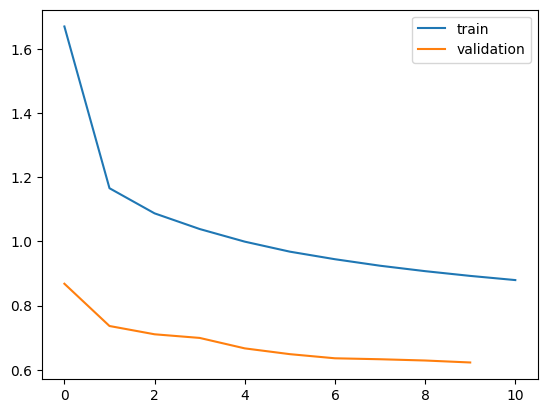

100%|██████████████████████████████████████████████████████████████████████████████| 5506/5506 [31:54<00:00,  2.88it/s]

validation loss = 0.6124613387131363


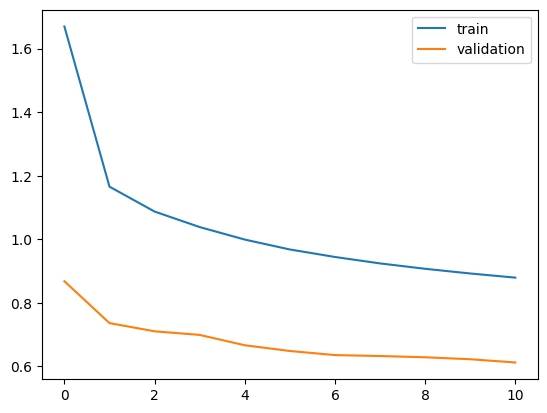

Starting epoch 11:


100%|██████████████████████████████████████████████████████████████████████████| 33010/33010 [5:36:06<00:00,  1.64it/s]

train loss = 0.8675730350817553


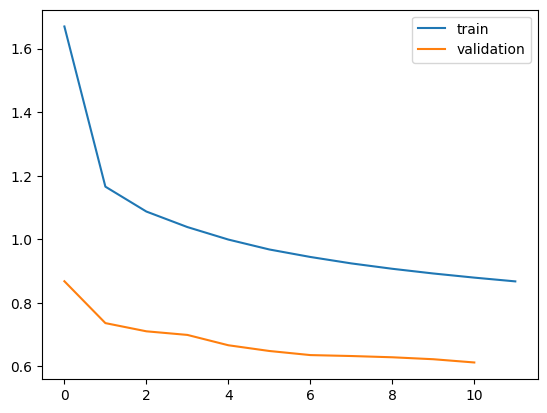

100%|███████████████████████████████████████| 5506/5506 [32:40<00:00,  2.81it/s]

validation loss = 0.6036355020263214


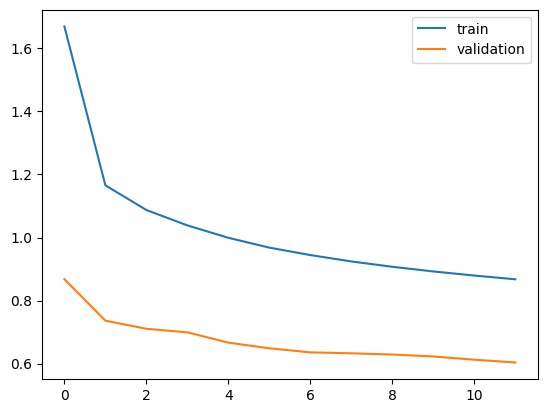

Starting epoch 12:


  6%|██▎                                 | 2142/33010 [14:58<3:35:41,  2.39it/s]


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
from transformers import AdamW
import torch

# Define hyperparameters
hyper_params = {
    "optimizer": "AdamW",  # Changed to AdamW for better integration with Transformers
    "batch_size": 256,
    "num_epochs": 20,
    "learning_rate": 1e-6,
    "ratio_images_to_use": ratio_images_to_use,
    "number_outputs": number_outputs
}

# Choose the optimizer based on the hyperparameters
if hyper_params['optimizer'] == "AdamW":
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=hyper_params['learning_rate'])
else:
    optimizer = torch.optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=hyper_params['learning_rate'])

# Loss function
criterion = torch.nn.CrossEntropyLoss(reduction='sum')

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# Send the model to the device (GPU/CPU)
model = model.to(device)

# Load checkpoint if available
start_epoch = 0  # Default start epoch is 0
checkpoint_path = '/home/student/khan/vqa2/RSVQAxBEN/Model_fe4e755d3b614dcaa5f4d81b38039061_10.tar'

try:
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    losses = checkpoint['losses']
    number_iters = checkpoint['number_iters']
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resuming training from epoch {start_epoch}...")
except FileNotFoundError:
    print(f"No checkpoint found at '{checkpoint_path}'. Starting training from scratch.")

# Create data loaders
loaders = {}
for step in ["train", "validation"]:
    train = step == "train"
    loaders[step] = torch.utils.data.DataLoader(dataset[step], batch_size=hyper_params['batch_size'], shuffle=train, num_workers=0)

# Experiment logging setup (assuming you're using Comet or similar)
experiment = Experiment(api_key="HNULa903fHJnPU0VtACPBOTBX", project_name="vqaxben", workspace="your_workspace", log_code=True)
experiment.log_parameters(hyper_params)

# Initialize variables to track losses and iterations
if 'losses' not in globals():
    losses = {"train": [], "validation": []}
if 'number_iters' not in globals():
    number_iters = {"train": 0, "validation": 0}

# Training loop
for epoch in range(start_epoch, hyper_params['num_epochs']):
    print(f"Starting epoch {epoch}:")

    for step in ["train", "validation"]:
        if step == "train":
            model.train()
        else:
            model.eval()

        total_correct = 0
        with torch.set_grad_enabled(step == "train"):
            if len(losses[step]) <= epoch:
                losses[step].append(0)

            for i, data in enumerate(tqdm(loaders[step])):
                if step == "train":
                    question, answer, image = data
                else:
                    question, answer, image, type_str, image_original, _ = data

                # Tokenize and encode the questions if they are still in string format
                if isinstance(question, str) or isinstance(question[0], str):
                    encoded_input = tokenizer(question, return_tensors='pt', padding=True, truncation=True)
                    question = encoded_input['input_ids']  # Get the input IDs tensor

                # Move data to the appropriate device
                question = question.to(device)
                answer = answer.to(device).long()  # Ensure the answer tensor is of type LongTensor
                image = image.float().to(device)

                # Run the model and compute the loss
                pred = model(image, question)
                loss = criterion(pred, answer)
                if step == "train":
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                losses[step][epoch] += loss.cpu().item()

                # Compute the accuracy
                _, predicted = torch.max(pred.data, 1)
                batch_correct = (predicted == answer.data).sum()
                total_correct += batch_correct

                # Logging
                experiment.log_metric(step + "_loss_batch", loss.cpu().item() / question.size(0), step=number_iters[step])
                experiment.log_metric(step + "_accuracy_batch", batch_correct / question.size(0), step=number_iters[step])
                number_iters[step] += 1

            losses[step][epoch] /= len(dataset[step])
            print(f"{step} loss = {losses[step][epoch]}")
            # Logging
            experiment.log_metric(step + "_loss", losses[step][epoch], epoch=epoch)
            experiment.log_metric(step + "_accuracy", total_correct / len(dataset[step]), epoch=epoch)

        if epoch > 0:
            plt.figure()
            handles = []
            handles.append(plt.plot(losses["train"], label="train")[0])
            handles.append(plt.plot(losses["validation"], label="validation")[0])
            plt.legend(handles=handles)
            plt.show()

        # Save the model after every 2 epochs
        if (epoch + 1) % 2 == 0:
            torch.save({
                "model_state_dict": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "losses": losses,
                "number_iters": number_iters,
                "epoch": epoch
            }, f"Model_{experiment.get_key()}_{epoch + 1}.tar")

# End the experiment
experiment.end()


In [ ]:
model_name = "Model_1ded1d8eaa904d50ab0cb6723d1678c1_12.tar"

import copy
selected_answers = copy.deepcopy(dataset["train"].selected_answers)
# dataset = None
# loaders = None
import gc
gc.collect()

ratio_images_to_use=1
# test_dataset = VQALoader("/home/student/khan/vqa/Images", data_files["test"]["images"], data_files["test"]["questions"], data_files["test"]["answers"], encoder_questions, encoder_answers, train=False, transform=transform, selected_answers=selected_answers, ratio_images_to_use=ratio_images_to_use, patch_size=patch_size)
# test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=hyper_params['batch_size'], shuffle=False, num_workers=0)
checkpoint = torch.load(model_name)

model = VQAModel(number_outputs=number_outputs)
model.load_state_dict(checkpoint['model_state_dict'])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

model = model.to(device)

model.eval()

Using device: cuda


VQAModel(
  (dropoutV): Dropout(p=0.5, inplace=False)
  (dropoutQ): Dropout(p=0.5, inplace=False)
  (dropoutF): Dropout(p=0.5, inplace=False)
  (seq2vec): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
             

In [ ]:
selected_answers

['no',
 'yes',
 'None',
 'agricultural areas',
 'non-irrigated arable land',
 'pastures',
 'broad-leaved forest',
 'water bodies',
 'agricultural areas and artificial areas',
 'arable land',
 'artificial areas',
 'marine waters',
 'transitional woodland/shrub',
 'forests',
 'forests and heterogeneous agricultural areas',
 'arable land, forests and heterogeneous agricultural areas',
 'broad-leaved forest and transitional woodland/shrub',
 'non-irrigated arable land and pastures',
 'arable land and heterogeneous agricultural areas',
 'land principally occupied by agriculture, with significant areas of natural vegetation',
 'complex cultivation patterns',
 'agricultural areas, arable land and non-irrigated arable land',
 'heterogeneous agricultural areas',
 'mixed forest',
 'broad-leaved forest and land principally occupied by agriculture, with significant areas of natural vegetation',
 'arable land and forests',
 'complex cultivation patterns and non-irrigated arable land',
 'coniferous 

In [ ]:
preds = []
GTs = []
types = []
img_ids = []
questions = []

with torch.no_grad():
    for i, data in enumerate(tqdm(test_loader)):
        question, answer, image, type_str, image_original, img_id = data

        # Tokenize the questions using BERT tokenizer
        encoded_input = model.tokenizer(question, return_tensors='pt', padding=True, truncation=True)
        question = encoded_input['input_ids'].to(device)

        image = image.float().to(device)

        # Get the model predictions
        pred = model(image, question)
        pred = np.argmax(pred.cpu().detach().numpy(), axis=1)

        for batch_index in range(question.shape[0]):
            preds.append(pred[batch_index])
            GTs.append(answer[batch_index].numpy())
            types.append(type_str[batch_index])
            img_ids.append(img_id[batch_index].numpy())
            questions.append(model.tokenizer.decode(question[batch_index,...].cpu().numpy()))

# Save the results
np.save("out_ep_12.npy", {"preds":preds,"GTs":GTs,"types":types,"questions": questions, "img_ids":img_ids,"selected_answers":selected_answers})


100%|███████████████████████████████████| 11409/11409 [1:05:59<00:00,  2.88it/s]


In [ ]:
import numpy as np
results = np.load("out_ep_12.npy", allow_pickle=True).item()

In [ ]:
from sklearn.metrics import accuracy_score

global_acc = accuracy_score(results["GTs"], results["preds"])

yn_preds = []
yn_gts = []
LC_preds = []
LC_gts = []

for i, ans in enumerate(results["GTs"]):
    if selected_answers[ans] == "yes" or selected_answers[ans] == "no":
        yn_preds.append(results["preds"][i])
        yn_gts.append(ans)
    else:
        LC_preds.append(results["preds"][i])
        LC_gts.append(results["GTs"][i])

yn_acc = accuracy_score(yn_gts, yn_preds)
LC_acc = accuracy_score(LC_gts, LC_preds)

print(f"Global accuracy: {'{:.2f}'.format(global_acc*100)}%")
print(f"Yes/No accuracy: {'{:.2f}'.format(yn_acc*100)}%")
print(f"LC accuracy: {'{:.2f}'.format(LC_acc*100)}%")

Global accuracy: 74.73%
Yes/No accuracy: 85.37%
LC accuracy: 22.84%


/tmp/ipykernel_204534/4059763627.py:19: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([''] + selected_answers[:number_to_plot], rotation = 45, ha="left")
/tmp/ipykernel_204534/4059763627.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([''] + selected_answers[:number_to_plot])


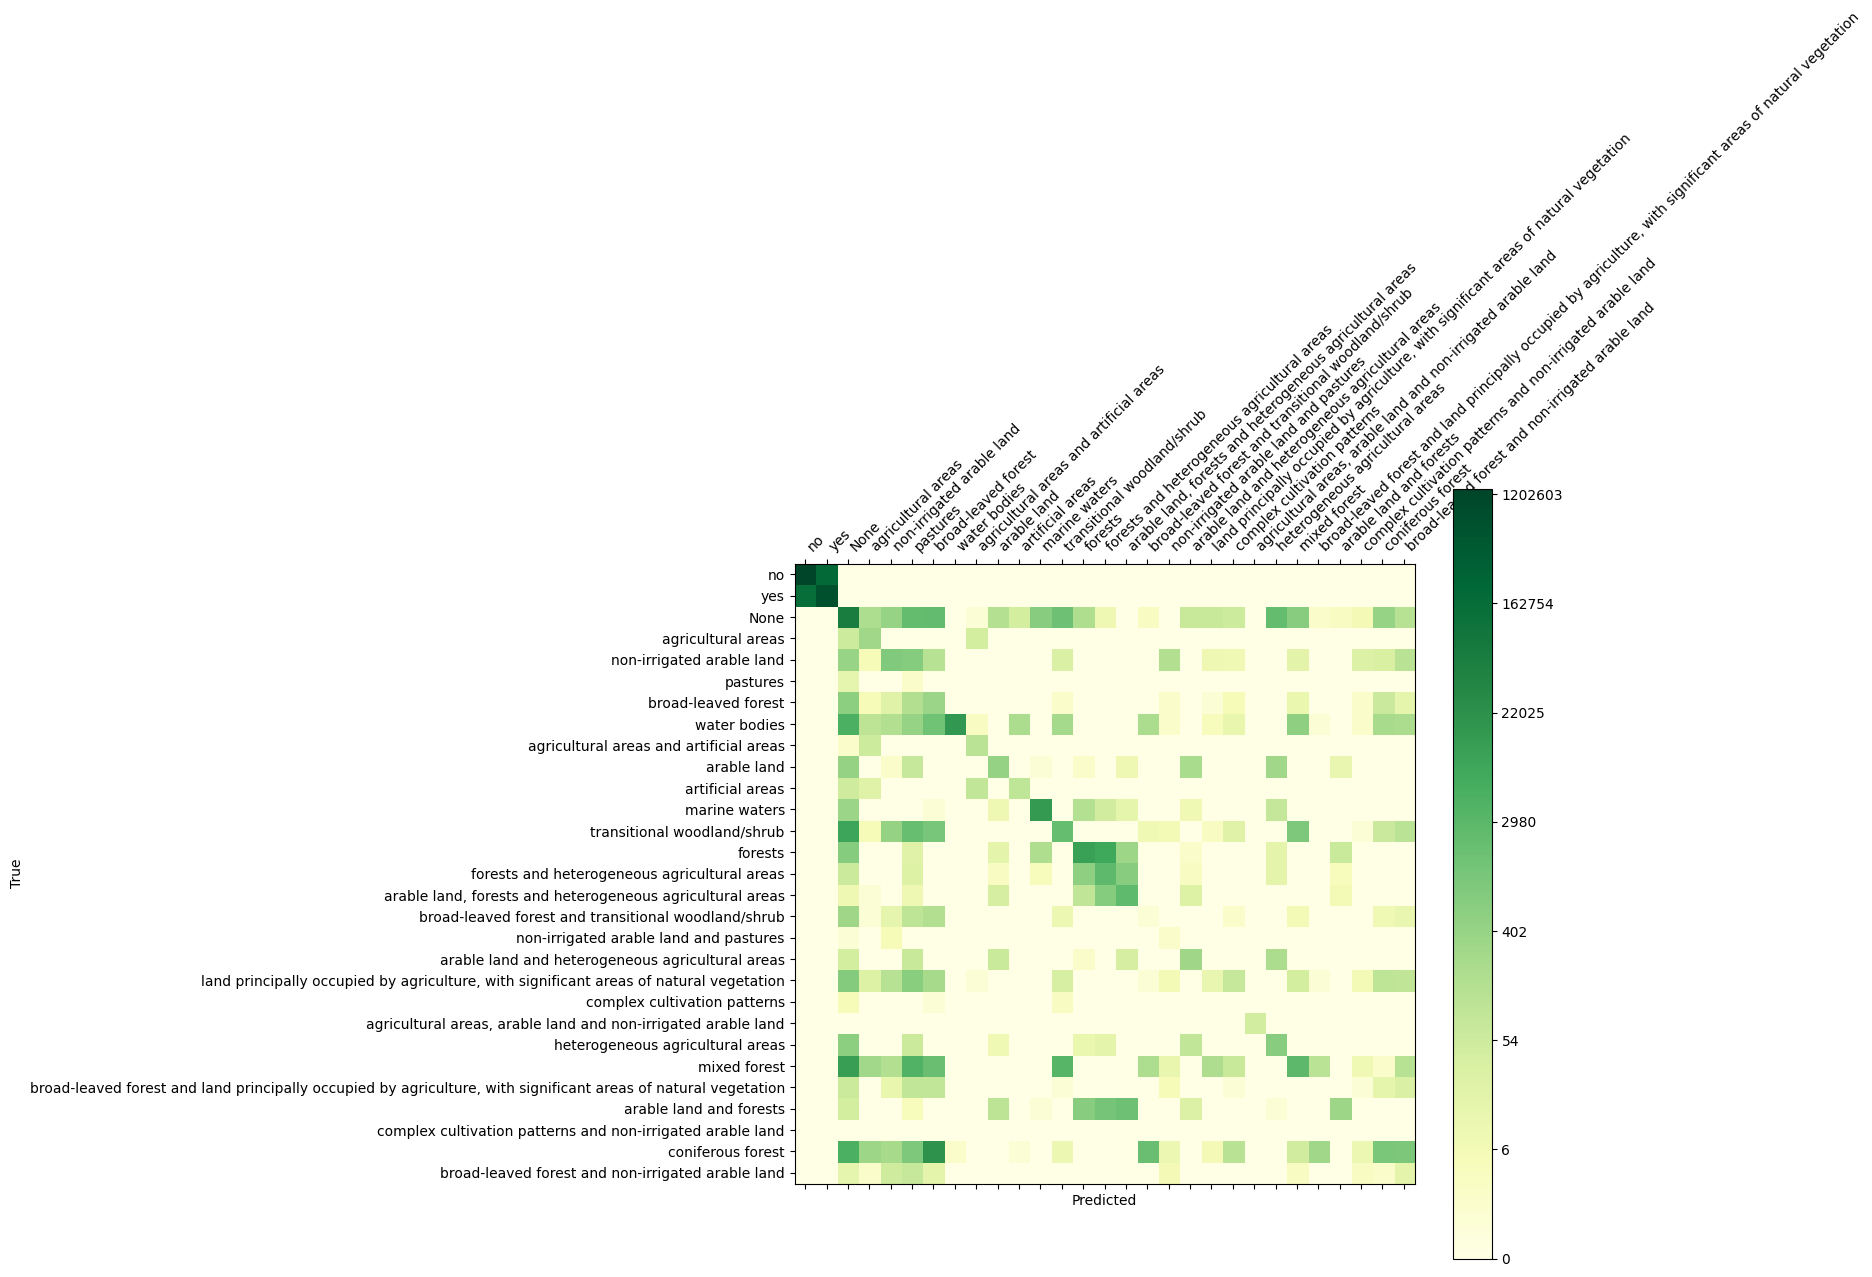

In [ ]:
from sklearn.metrics import confusion_matrix

mat = confusion_matrix(results["GTs"], results["preds"])

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib as mpl

number_to_plot = 29#len(selected_answers)

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
cax = ax.matshow(np.log(mat+1)[:number_to_plot,:number_to_plot], cmap="YlGn")
colorbar_ticks = np.array([0,2,4,6,8,10,12,14])
cbar = fig.colorbar(cax)
cbar.set_ticks(colorbar_ticks)
cbar.set_ticklabels(['{:.0f}'.format(x) for x in np.exp(colorbar_ticks)-1])
if number_to_plot < 30:
    ax.set_xticklabels([''] + selected_answers[:number_to_plot], rotation = 45, ha="left")
    ax.set_yticklabels([''] + selected_answers[:number_to_plot])
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
else:
    ax.set_xticks([], [])
    ax.set_yticks([], [])

plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
fig.savefig('confusion_matrix_' + str(number_to_plot) + '.svg')

In [ ]:
count = 0
for index in range(len(results['questions'])):
    if selected_answers[results['GTs'][index]] == 'arable land, forests, heterogeneous agricultural areas, inland waters and urban fabric':
        count += 1
print(count/len(results['questions'])*100)

0.005136147280050485


In [ ]:
with open("RSVQAxBEN_split_test_images.json") as json_data:
    imagesJSON = json.load(json_data)

print(imagesJSON['images'][249459])

{'id': 249459, 'date_added': 1607969006.2150314, 'original_name': 'S2B_MSIL2A_20170709T094029_0_26.tif', 'sensor': 'S2', 'upperleft_map_x': 499980, 'upperleft_map_y': 7068840, 'res_x': '10m', 'res_y': '10m', 'people_id': 0, 'type': 'RGB', 'questions_ids': [6236475, 6236476, 6236477, 6236478, 6236479, 6236480, 6236481, 6236482, 6236483, 6236484, 6236485, 6236486, 6236487, 6236488, 6236489, 6236490, 6236491, 6236492, 6236493, 6236494, 6236495, 6236496, 6236497, 6236498, 6236499], 'active': True}


====1950360====
[CLS] are some water bodies present? [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]
pred: yes
GT: no
====1950361====
[CLS] are some discontinuous urban fabric present? [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]
pred: yes
GT: yes
====1950362====
[CLS] are some transitional woodland / shrub present? [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]
pred: no
GT: yes
====1950363====
[CLS] are artificial areas and wetlands present in the image? [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]
pred: no
GT: no
====1950364====
[CLS] are continuous urban fabric or construction sites and discontinuous urban fabric present? [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]
pred: no
GT: no
====1950365====
[CLS] are there water courses and dump s

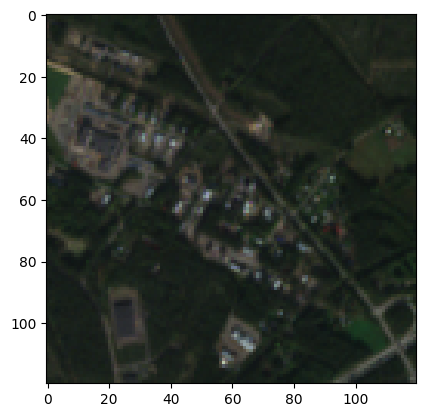

In [ ]:
import matplotlib
import os

selected_answers = results['selected_answers']

for index in range(len(results['questions'])):
    if results['img_ids'][index] == 357472:
        print(f"===={index}====")
        print(results['questions'][index])
        print(f"pred: {selected_answers[results['preds'][index]]}")
        print(f"GT: {selected_answers[results['GTs'][index]]}")
        print("=============")
        #test = matplotlib.image.imread(os.path.join('Images',str(results['img_ids'][index]))+'.tif')
        #print(np.mean(test))
        plt.imshow(matplotlib.image.imread(os.path.join('/home/student/khan/vqa/Images',str(results['img_ids'][index]))+'.tif'))


In [ ]:
import matplotlib
import os

selected_answers = results['selected_answers']

for index in range(len(results['questions'])):
    if results['img_ids'][index] == 1416:
        print(results['questions'][index])
        print(selected_answers[results['preds'][index]])
        print(selected_answers[results['GTs'][index]])
        #test = matplotlib.image.imread(os.path.join('Images',str(results['img_ids'][index]))+'.tif')
        #print(np.mean(test))
        plt.imshow(matplotlib.image.imread(os.path.join('/home/student/khan/vqa/Images',str(results['img_ids'][index]))+'.tif'))

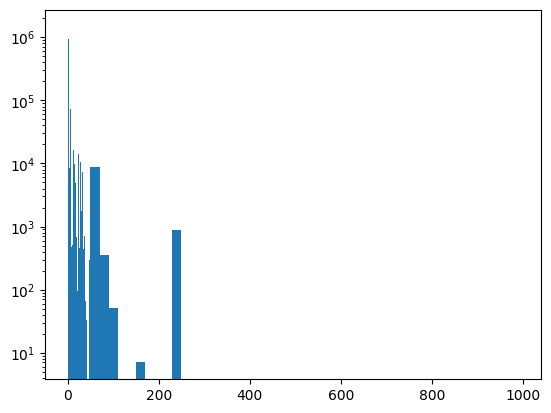

In [ ]:
bins = [x for x in range(50)] + [x for x in np.arange(50,1000,20)]
plt.hist([x.item() for x in results["preds"]], bins=bins)
plt.yscale('log')
plt.show()

In [ ]:
number_samples = len(results["types"])

predsLC = np.select(np.array(results["types"]) == "LC", np.array(results["preds"]))
predsLC

array(7)

In [ ]:
# End of code